In [1]:
# first let's import the libraries that we will need.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# then we read the data.
data = pd.read_csv("mnist_train.csv")

In [3]:
# we take a look at the data.
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# so we have 784 features. in our input layer we will have 784 neurons.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


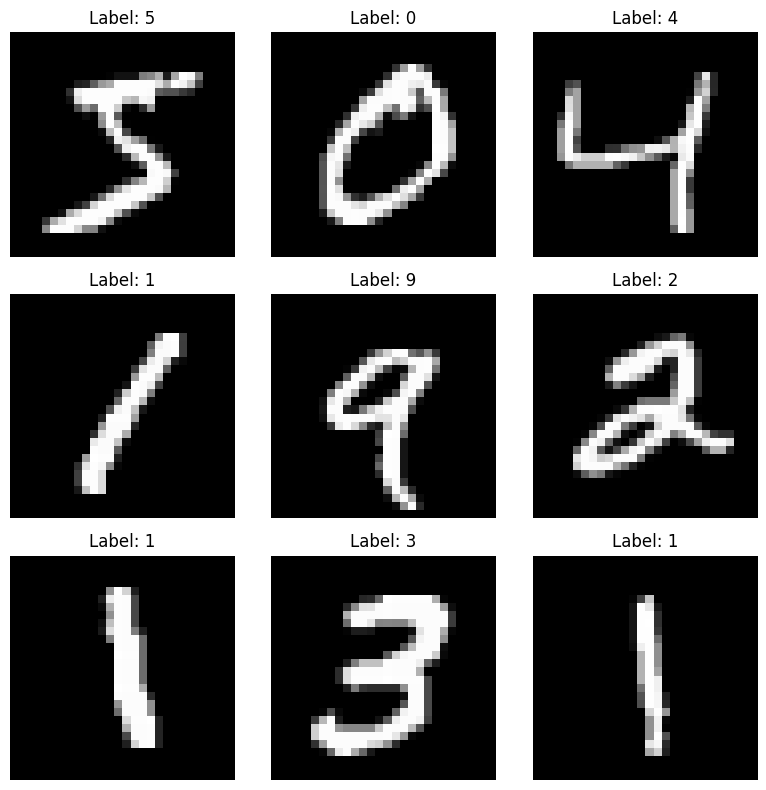

In [8]:
# Visualization with subplot for 9 rows.
figure,axes = plt.subplots(3,3,figsize=(8,8))
axes = axes.flatten()
for i in range(9):
    row = data.iloc[i]
    label = row["label"]
    image = np.array(row[1:]).reshape(28,28)
    ax = axes[i]
    ax.set_title(f"Label: {label}")
    ax.imshow(image, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
# Split the data
X_train = data.iloc[:, 1:].values
Y_labels = data.iloc[:, 0].values

# Normalize pixel values
X_train = X_train / 255.0

# One-hot encode labels
def one_hot_encode(labels, num_classes=10):
    one_hot = np.zeros((labels.size, num_classes))
    one_hot[np.arange(labels.size), labels] = 1
    return one_hot

Y_train = one_hot_encode(Y_labels)


In [5]:
# Now let's start making our neural network. We will have 784 neurons in the input layer, 128 in the hidden 
# layer and 10 in the output layer for our digts(0-9).
# The first step is to randomly initialize the weights and biases(0 for biases).
def initialize_weights(input_size, hidden_size, output_size):
    # Between input and hidden layer.
    W1 = np.random.randn(hidden_size, input_size) * 0.01 #times 0.01 to keep the weights small for the first iteration.
    b1 = np.zeros((hidden_size, 1))
    
    # Between hidden and output layer.
    W2 = np.random.randn(output_size, hidden_size) * 0.01
    b2 = np.zeros((output_size, 1))
    
    return W1, b1, W2, b2 

In [6]:
# Forward propagation. First let's define the activation functions.
def sigmoid(Z):
    return 1/(1 + np.exp(-Z))

def softmax(Z):
    expZ = np.exp(Z - np.max(Z)) # to avoid overflow
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [8]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [9]:
# Now we will implement our loss function. We will use Cross-Entropy
def compute_loss(Y_true, Y_pred):
    return -np.sum(Y_true * np.log(Y_pred + 1e-8)) #avoid log(0)

In [15]:
# Time for Backpropagation. First let's calculate the gradients.
# dE/dZ2 = A2 - Y_true because of combining softmax and cross-entropy
def backward_propagation(X, Y, Z1, A1, A2, W2):
    dZ2 = A2 - Y
    
    dW2 = np.dot(dZ2, A1.T)
    db2 = dZ2
    
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * A1 * (1 - A1) # Sigmoid derivative of A1
    
    dW1 = np.dot(dZ1, X.T)
    db1 = dZ1

    return dW1, db1, dW2, db2

In [11]:
# Now let's update the weights.
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

In [16]:
# Next step is to train the neural net
epochs = 10 # Times to loop our training
learning_rate = 0.01
# intialize the weights
input_size = 784
hidden_size = 128
output_size = 10
W1, b1, W2, b2 = initialize_weights(input_size, hidden_size, output_size)

for epoch in range(epochs):
    E = 0

    for i in range(X_train.shape[0]):
        X = X_train[i].reshape(-1, 1)
        Y = Y_train[i].reshape(-1, 1)

        # Forward pass
        Z1, A1, Z2, A2 = forward_propagation(X, W1, b1, W2, b2)
        
        # E(total loss)
        loss = compute_loss(Y, A2)
        E += loss

        # Backward pass
        dW1, db1, dW2, db2 = backward_propagation(X, Y, Z1, A1, A2, W2)

        # Update weights
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)
        
    avg_loss = E/X_train.shape[0]
    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch: 1/10, Loss: 0.4651
Epoch: 2/10, Loss: 0.2143
Epoch: 3/10, Loss: 0.1593
Epoch: 4/10, Loss: 0.1266
Epoch: 5/10, Loss: 0.1050
Epoch: 6/10, Loss: 0.0895
Epoch: 7/10, Loss: 0.0777
Epoch: 8/10, Loss: 0.0683
Epoch: 9/10, Loss: 0.0606
Epoch: 10/10, Loss: 0.0542


In [23]:
# Now to test the model using the test data
test_data = pd.read_csv("mnist_test.csv")
X_test = test_data.iloc[:, 1:].values / 255.0 # Normalize

In [24]:
def predict(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    return np.argmax(A2, axis=0)

In [25]:
predictions = []

for i in range(X_test.shape[0]):
    X = X_test[i].reshape(-1, 1)
    pred = predict(X, W1, b1, W2, b2)
    predictions.append(pred[0])

In [ ]:
# save predictions
output = pd.Dataframe({"ImageId": np.arange(1, len(predictions)+1),
                      "Label": predictions
                      })
output.to_csv("submission.csv", index=False)

# References:
[Medium_1](https://medium.com/@ombaval/building-a-simple-neural-network-from-scratch-for-mnist-digit-recognition-without-using-7005a7733418)

[Medium_2](https://medium.com/@cmukesh8688/activation-functions-sigmoid-tanh-relu-leaky-relu-softmax-50d3778dcea5)

[github_1](https://github.com/OmBaval/Neural-Network-from-scratch-without-TensorFlow-PyTorch/blob/main/Neural%20Network%20from%20Scratch.ipynb)

[Numpy](https://numpy.org/doc/2.3/user/absolute_beginners.html)

[GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/mnist-dataset/)

[Kaggle_1](https://www.kaggle.com/code/jedrzejdudzicz/mnist-dataset-100-accuracy/data)

[Kaggle_2](https://www.kaggle.com/code/manzoormahmood/mnist-neural-network-from-scratch)